# 智境情绪能力测评：预测试数据分析

本 Notebook 依据《预测试数据分析方案（改良版）》分析 `zhijing-attempt-details-全部.csv`。分析重点是答卷质量、随机抽题覆盖、题目表现、低正确率题目诊断和因素分析可行性，而不是建立常模或比较个体能力。

**口径说明**：网站现行的“标签得分率”对单标准答案题是 0/100，对多标准答案题采用 Dice/F1 部分计分，并非统一的二分变量。因此本文同时构造：①严格完全识别指标 `X_exact`（标签得分率=100 时为 1，否则为 0），用于方案中的二分项目分析；②网站原始标签得分率，用于补充展示部分识别表现。模块 Y 的 CSV 是网站计算后的强度匹配得分率，而非单一 1–5 原始等级；原始强度分析则从“用户情绪强度”拆分后进行。

In [37]:
from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 内部变量保留英文便于编程；展示和 CSV 导出时转为中文表头。
CN = {
 'attempt_id':'答卷编号','submitted_at':'提交时间','total_seconds':'总作答时间（秒）','overall_score':'答卷综合得分率','n_items':'作答题数','count':'计数','unique':'唯一值数','top':'众数','freq':'众数频次','mean':'平均值','std':'标准差','min':'最小值','max':'最大值',
 'mean_label':'平均标签得分率','mean_strength':'平均强度得分率','short_empirical':'命中经验短时阈值','low_empirical':'命中经验低分阈值',
 'short_distribution':'命中分布短时阈值','low_distribution':'命中分布低分阈值','suspect':'重点可疑','review_reason':'复核原因','included_main':'纳入主分析',
 'item_id':'题目编号','position':'题目位置','n':'有效作答人数','n_administered':'抽中人数','title':'题目标题','modality':'素材模态','ability':'能力类型','option_type':'选项形式',
 'quota':'每卷组合配额','pool_size':'组合题库数','expected_n':'期望作答人数','actual_expected_ratio':'实际期望比','combination':'抽题组合',
 'items':'题目数','actual_min':'实际最小人数','actual_max':'实际最大人数','actual_mean':'实际平均人数','within_cv':'组合内覆盖变异系数',
 'exact_rate':'严格完全识别率','exact_ci_low':'完全识别率95%区间下限','exact_ci_high':'完全识别率95%区间上限','mean_partial_label':'平均部分标签得分',
 'mean_label_recall':'平均标签召回率','mean_label_precision':'平均标签准确率','mean_label_jaccard':'平均Jaccard相似度','mean_nonstandard_selection_rate':'平均非标准标签误选率',
 'corrected_item_total_r':'同能力校正题总相关','D_27':'高低27%组D值','mean_seconds':'平均作答时间（秒）','median_seconds':'作答时间中位数（秒）','mean_item_score':'平均单题综合得分','mean_time':'平均作答时间（秒）',
 'emotion':'情绪标签','is_standard':'是否标准标签','selected_n':'选择人次','selector_rest_mean':'选择者同能力其余题均分','selection_rate':'选择率',
 'mean_strength_match':'平均强度匹配得分','sd_strength_match':'强度匹配得分标准差','median_strength_match':'强度匹配得分中位数',
 'selected_emotion_ratings':'情绪强度评定数','mean_intensity':'标签级平均强度','sd_intensity':'标签级强度标准差','median_intensity':'标签级强度中位数',
 'q1':'强度下四分位数','q3':'强度上四分位数','floor_rate':'强度地板比例','ceiling_rate':'强度天花板比例','normalized_mean':'标签级标准化平均强度',
 'person_n':'被试级有效人数','person_mean_intensity':'被试级平均强度','person_sd_intensity':'被试级强度标准差','standard_emotion_mean_intensity':'标准情绪平均强度','nonstandard_emotion_mean_intensity':'非标准情绪平均强度',
 'top_choice':'最高频选择','top_choice_rate':'最高频选择率','correct_emotions':'标准情绪','top_is_standard':'最高频选择是否为标准情绪',
 'initial_recommendation':'统计初筛建议','expert_review_conclusion':'专家复核结论','final_decision':'最终决策','review_notes':'复核备注',
 'n_all':'全部答卷作答人数','exact_rate_all':'全部答卷完全识别率','partial_label_all':'全部答卷部分标签得分','strength_match_all':'全部答卷强度匹配得分',
 'exact_rate_difference':'完全识别率差','partial_label_difference':'部分标签得分差','strength_match_difference':'强度匹配得分差',
 'max_sensitivity_difference':'最大敏感性差值','warning_count':'统计预警项数','warning_reasons':'统计预警原因',
 'group_dimension':'分组维度','group_value':'属性类型','item_count':'题目数','response_count':'作答记录数','item_n_mean':'每题样本量均值','item_n_median':'每题样本量中位数',
 'item_n_min':'每题样本量最小值','item_n_max':'每题样本量最大值','corrected_r_median':'校正题总相关中位数','corrected_r_valid_items':'相关有效题数',
 'D_27_median':'D值中位数','sensitivity_median':'敏感性差值中位数','sensitivity_max':'敏感性差值最大值','low_sample_item_rate':'样本不足题目比例',
 'low_exact_item_rate':'低完全识别率题目比例','negative_r_item_rate':'负相关题目比例','retain_item_rate':'暂时保留题目比例'}
CN.update({f'level_{i}_n':f'强度{i}级人次' for i in range(1,6)})
def chinese_table(frame):
    result=frame.rename(columns=CN,index=CN)
    if isinstance(result.index,pd.MultiIndex): result.index=result.index.set_names([CN.get(n,n) for n in result.index.names])
    else: result=result.rename_axis(index=CN.get(result.index.name,result.index.name))
    if isinstance(result.columns,pd.MultiIndex): result.columns=result.columns.set_names([CN.get(n,n) for n in result.columns.names])
    else: result=result.rename_axis(columns=CN.get(result.columns.name,result.columns.name))
    return result
def export_table(frame,path,index=False):
    chinese_table(frame).to_csv(path,index=index,encoding='utf-8-sig')

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'zhijing-attempt-details-全部.csv').exists():
    BASE_DIR = BASE_DIR / 'predataAnalysis'
DATA_FILE = BASE_DIR / 'zhijing-attempt-details-全部.csv'
if not DATA_FILE.exists():
    raise FileNotFoundError(f'未找到数据文件：{DATA_FILE.resolve()}')
OUTPUT_DIR = DATA_FILE.parent / '预测试分析输出'
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 20260818
print('数据文件：', DATA_FILE.resolve())
print('输出目录：', OUTPUT_DIR.resolve())

数据文件： /home/lyh/emotion-test/predataAnalysis/zhijing-attempt-details-全部.csv
输出目录： /home/lyh/emotion-test/predataAnalysis/预测试分析输出


## 1. 读取、标准化字段与基本合法性检查

保留原始数据不变，另建便于编程的英文字段。`NA` 仅表示未抽到；当前长表中的每一行都是实际抽中的题目。多选情绪与强度用全角竖线 `｜` 一一对应。

In [38]:
raw = pd.read_csv(DATA_FILE, encoding='utf-8-sig')
rename = {
 '匿名答卷编号':'attempt_id','提交时间（北京时间）':'submitted_at','答卷综合得分率（%）':'attempt_score',
 '题号':'position','题目编号':'item_id','题目标题':'item_title','素材模态':'modality','能力类型':'ability',
 '选项形式':'option_type','题目分值':'points','用户选择情绪':'selected_emotions','用户情绪强度':'selected_strengths',
 '标准情绪':'correct_emotions','标准情绪强度':'standard_strengths','是否看过素材':'watched','作答状态':'status',
 '标签得分率（%）':'label_score','强度得分率（%）':'strength_score','单题综合得分率（%）':'item_score',
 '单题实得分':'earned_points','作答用时（秒）':'response_seconds','修改次数':'modifications'}
missing_cols = sorted(set(rename) - set(raw.columns))
assert not missing_cols, f'CSV 缺少字段：{missing_cols}'
df = raw.rename(columns=rename).copy()
df['submitted_at'] = pd.to_datetime(df['submitted_at'], errors='coerce')
num_cols = ['attempt_score','position','points','label_score','strength_score','item_score','earned_points','response_seconds','modifications']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df['X_exact'] = np.isclose(df['label_score'], 100).astype(int)
df['label_partial_01'] = df['label_score'] / 100
df['strength_match_01'] = df['strength_score'] / 100
df['selected_list'] = df['selected_emotions'].fillna('').astype(str).str.split('｜')
df['selected_strength_list'] = df['selected_strengths'].fillna('').astype(str).str.split('｜')
df['correct_list'] = df['correct_emotions'].fillna('').astype(str).str.split('｜')
df['standard_strength_list'] = df['standard_strengths'].fillna('').astype(str).str.split('｜')

checks = pd.Series({
 '记录数':len(df), '答卷数':df['attempt_id'].nunique(), '母题数':df['item_id'].nunique(),
 '每答卷题数最小值':df.groupby('attempt_id').size().min(), '每答卷题数最大值':df.groupby('attempt_id').size().max(),
 '答卷-题目重复行':df.duplicated(['attempt_id','item_id']).sum(),
 '非已作答记录':(~df['status'].eq('已作答')).sum(),
 '标签分越界':(~df['label_score'].between(0,100)).sum(), '强度分越界':(~df['strength_score'].between(0,100)).sum(),
 '强度配对长度不一致':sum(len(a)!=len(b) for a,b in zip(df['selected_list'],df['selected_strength_list']))
})
display(checks.to_frame('结果'))
assert checks['答卷-题目重复行'] == 0 and checks['每答卷题数最小值'] == checks['每答卷题数最大值'] == 24


,结果
记录数,3264
答卷数,136
母题数,147
每答卷题数最小值,24
每答卷题数最大值,24
答卷-题目重复行,0
非已作答记录,0
标签分越界,0
强度分越界,0
强度配对长度不一致,0


## 2. 答卷层面的异常筛选

总作答时间由 24 道题的有效作答时间相加得到。先展示经验阈值（得分低于 30 且总时间少于 400 秒），同时用分布型阈值辅助复核：短时阈值取 `Q1 - 1.5×IQR`（下限不小于 0），低分阈值同理。仅因低分或短时不会自动排除；两者同时命中才标为重点可疑。主分析默认排除重点可疑答卷，敏感性分析保留全部答卷。

In [39]:
attempts = (df.groupby('attempt_id').agg(submitted_at=('submitted_at','first'), total_seconds=('response_seconds','sum'),
                overall_score=('attempt_score','first'), n_items=('item_id','size'),
                mean_label=('label_score','mean'), mean_strength=('strength_score','mean')).reset_index())
def lower_fence(s):
    q1, q3 = s.quantile([.25,.75]); return max(0, q1 - 1.5*(q3-q1))
time_cut = lower_fence(attempts['total_seconds'])
score_cut = lower_fence(attempts['overall_score'])
attempts['short_empirical'] = attempts['total_seconds'] < 400
attempts['low_empirical'] = attempts['overall_score'] < 30
attempts['short_distribution'] = attempts['total_seconds'] < time_cut
attempts['low_distribution'] = attempts['overall_score'] < score_cut
attempts['suspect'] = (attempts['short_empirical'] & attempts['low_empirical']) | (attempts['short_distribution'] & attempts['low_distribution'])
attempts['review_reason'] = np.select([attempts['suspect'], attempts['short_empirical']|attempts['short_distribution'], attempts['low_empirical']|attempts['low_distribution']],
 ['短时且低分：重点复核','仅短时：暂不删除','仅低分：原则保留'], default='未命中')
attempts['included_main'] = ~attempts['suspect']
print(f'分布型短时阈值={time_cut:.2f} 秒；分布型低分阈值={score_cut:.2f}；重点可疑={attempts.suspect.sum()} 份')
display(chinese_table(attempts.describe(include='all').T))
display(chinese_table(attempts.loc[attempts['review_reason']!='未命中'].sort_values(['suspect','total_seconds'],ascending=[False,True])))
export_table(attempts,OUTPUT_DIR/'异常答卷处理表.csv')
include_ids = set(attempts.loc[attempts['included_main'],'attempt_id'])
main = df[df['attempt_id'].isin(include_ids)].copy()
print('主分析答卷数：', main['attempt_id'].nunique(), '；敏感性分析答卷数：', df['attempt_id'].nunique())

分布型短时阈值=0.00 秒；分布型低分阈值=16.64；重点可疑=8 份


,计数,唯一值数,众数,众数频次,平均值,最小值,25%,50%,75%,最大值,标准差
答卷编号,136,136,ZJ202608131494BDB9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
提交时间,136,NaN,NaN,NaN,2026-08-16 04:43:08.823529472,2026-08-13 20:16:00,2026-08-16 11:20:00,2026-08-16 11:35:00,2026-08-16 11:43:00,2026-08-16 13:24:00,NaN
总作答时间（秒）,136.0,NaN,NaN,NaN,814.024412,38.84,593.6525,798.785,1017.455,1930.76,336.391985
答卷综合得分率,136.0,NaN,NaN,NaN,49.189191,5.76,41.49,50.535,58.0575,87.0,13.900229
作答题数,136.0,NaN,NaN,NaN,24.0,24.0,24.0,24.0,24.0,24.0,0.0
平均标签得分率,136.0,NaN,NaN,NaN,52.583793,6.25,45.084479,54.27125,61.414271,91.666667,14.193313
平均强度得分率,136.0,NaN,NaN,NaN,43.671728,3.819583,35.503542,44.84375,52.907917,81.25,14.10437
命中经验短时阈值,136,2,False,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
命中经验低分阈值,136,2,False,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
命中分布短时阈值,136,1,False,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,答卷编号,提交时间,总作答时间（秒）,答卷综合得分率,作答题数,平均标签得分率,平均强度得分率,命中经验短时阈值,命中经验低分阈值,命中分布短时阈值,命中分布低分阈值,重点可疑,复核原因,纳入主分析
41,ZJ20260816136E1227,2026-08-16 11:20:00,38.84,13.80,24,17.916667,9.010417,True,True,False,True,True,短时且低分：重点复核,False
20,ZJ2026081508C07905,2026-08-15 23:44:00,109.51,8.71,24,9.722500,5.382083,True,True,False,True,True,短时且低分：重点复核,False
23,ZJ2026081530EFBB7A,2026-08-15 23:43:00,123.36,17.66,24,19.722500,13.367917,True,True,False,False,True,短时且低分：重点复核,False
26,ZJ202608156B6462DB,2026-08-16 09:30:00,134.26,5.76,24,6.250000,3.819583,True,True,False,True,True,短时且低分：重点复核,False
30,ZJ20260815B6992A82,2026-08-15 23:13:00,157.44,11.90,24,14.166667,13.020833,True,True,False,True,True,短时且低分：重点复核,False
37,ZJ202608160A6834BD,2026-08-16 11:41:00,163.12,25.08,24,28.055833,20.138750,True,True,False,False,True,短时且低分：重点复核,False
110,ZJ20260816C63CA8EE,2026-08-16 12:02:00,180.25,29.25,24,35.695000,24.132083,True,True,False,False,True,短时且低分：重点复核,False
24,ZJ2026081555E6E754,2026-08-15 23:44:00,235.82,19.09,24,20.833750,14.583333,True,True,False,False,True,短时且低分：重点复核,False
80,ZJ2026081676E36766,2026-08-16 11:45:00,253.48,38.13,24,40.139167,34.548750,True,False,False,False,False,仅短时：暂不删除,True
29,ZJ20260815904AC83A,2026-08-16 00:08:00,359.85,39.37,24,42.520417,35.711667,True,False,False,False,False,仅短时：暂不删除,True


主分析答卷数： 128 ；敏感性分析答卷数： 136


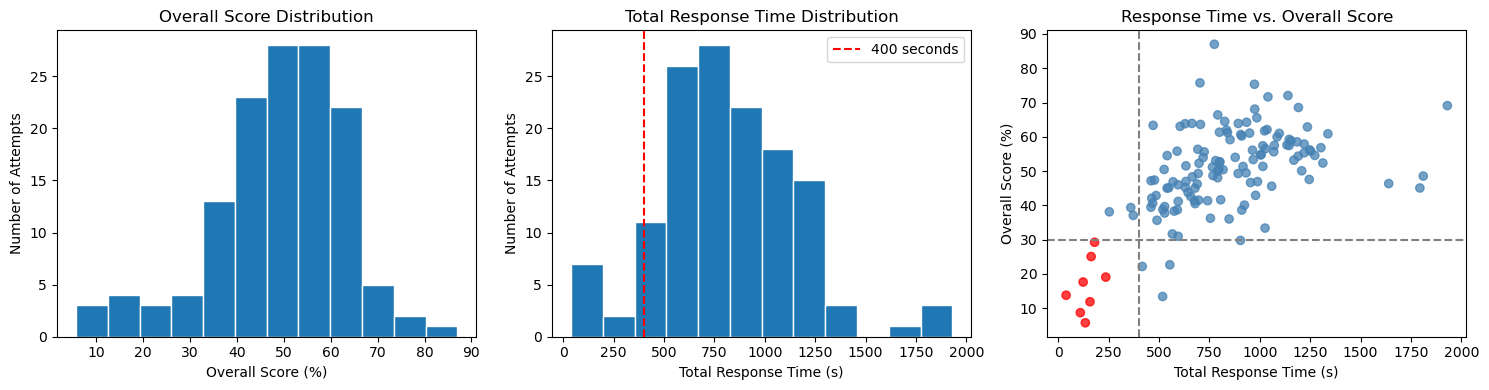

In [40]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].hist(attempts['overall_score'], bins=12, edgecolor='white'); axes[0].set(title='Overall Score Distribution',xlabel='Overall Score (%)',ylabel='Number of Attempts')
axes[1].hist(attempts['total_seconds'], bins=12, edgecolor='white'); axes[1].axvline(400,color='r',ls='--',label='400 seconds'); axes[1].set(title='Total Response Time Distribution',xlabel='Total Response Time (s)',ylabel='Number of Attempts'); axes[1].legend()
axes[2].scatter(attempts['total_seconds'],attempts['overall_score'],c=np.where(attempts['suspect'],'red','steelblue'),alpha=.75); axes[2].axvline(400,color='gray',ls='--'); axes[2].axhline(30,color='gray',ls='--'); axes[2].set(title='Response Time vs. Overall Score',xlabel='Total Response Time (s)',ylabel='Overall Score (%)')
plt.tight_layout(); plt.show()

## 3. 随机抽题覆盖与设计性缺失

每人按‘模态 × 单/多选 × 识别/推理’的固定配额作答 24 道题，未抽到题目在宽表中保持 `NaN`。本节先校验每份答卷的组合题数，再以组合内期望样本量为基准检查覆盖均衡性，并报告题目位置分布和任意两题的共同作答人数。

不符合预设组合配额的主分析答卷数： 0
实际每题样本量：最小=3，最大=64，整体均值=20.90；下表按抽题组合评估覆盖


,抽题组合,每卷组合配额,组合题库数,期望作答人数,题目数,实际最小人数,实际最大人数,实际平均人数,组合内覆盖变异系数
0,图像 / 单选题 / 情绪识别,2,28,9.143,28,3,15,9.143,0.348
1,图像 / 多选题 / 情绪推理,1,2,64.000,2,64,64,64.000,0.000
2,图像 / 多选题 / 情绪识别,3,22,17.455,22,11,29,17.455,0.218
3,文本 / 单选题 / 情绪推理,1,4,32.000,4,27,37,32.000,0.130
4,文本 / 单选题 / 情绪识别,1,10,12.800,10,9,18,12.800,0.217
5,文本 / 多选题 / 情绪推理,1,3,42.667,3,32,48,42.667,0.217
6,文本 / 多选题 / 情绪识别,3,12,32.000,12,21,40,32.000,0.190
7,视频 / 单选题 / 情绪推理,1,4,32.000,4,30,34,32.000,0.057
8,视频 / 单选题 / 情绪识别,1,19,6.737,19,3,12,6.737,0.349
9,视频 / 多选题 / 情绪推理,2,8,32.000,8,25,38,32.000,0.140


能力类型,情绪推理,情绪识别
题目位置,,
1,42,86
2,33,95
3,46,82
4,41,87
5,31,97
6,51,77
7,32,96
8,32,96
9,52,76


,共同作答人数
count,10731.000000
mean,3.292144
std,3.504027
min,0.000000
10%,0.000000
25%,1.000000
50%,2.000000
75%,5.000000
90%,8.000000
95%,10.000000


零共同作答题对比例： 19.3% ；至少10人共同作答比例： 6.6%


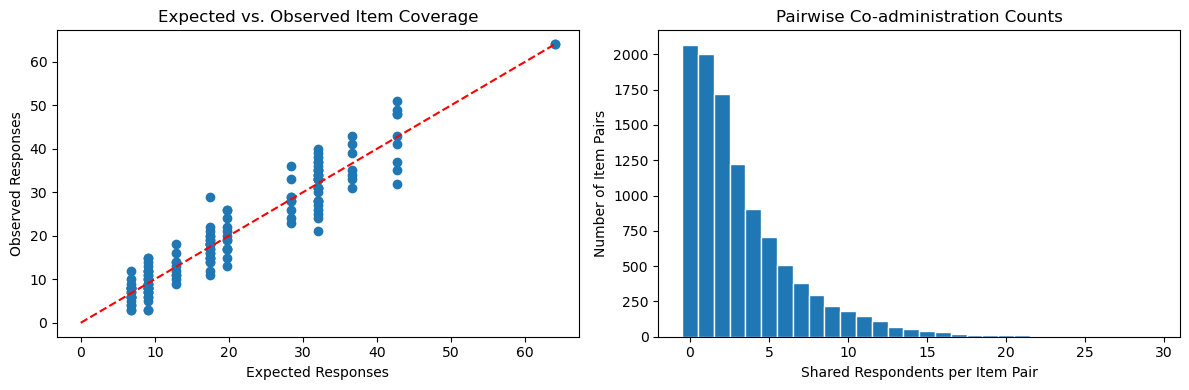

In [41]:
# 预测试每份卷按‘模态×单/多选×识别/推理’固定配额抽题，不能用 24/147 作为每题的统一期望。
QUOTAS = {
 ('图像','单选题','情绪识别'):2, ('图像','多选题','情绪识别'):3, ('图像','多选题','情绪推理'):1,
 ('文本','单选题','情绪识别'):1, ('文本','单选题','情绪推理'):1, ('文本','多选题','情绪识别'):3, ('文本','多选题','情绪推理'):1,
 ('音频','单选题','情绪识别'):2, ('音频','多选题','情绪识别'):2, ('音频','多选题','情绪推理'):2,
 ('视频','单选题','情绪识别'):1, ('视频','单选题','情绪推理'):1, ('视频','多选题','情绪识别'):2, ('视频','多选题','情绪推理'):2}
expected_combo=pd.Series(QUOTAS,name='expected').rename_axis(['modality','option_type','ability'])
observed_combo=(main.groupby(['attempt_id','modality','option_type','ability']).size().unstack(['modality','option_type','ability'],fill_value=0).reindex(columns=expected_combo.index,fill_value=0))
quota_violations=observed_combo.ne(expected_combo,axis=1).any(axis=1).sum()
print('不符合预设组合配额的主分析答卷数：',quota_violations)
assert quota_violations == 0, '实际答卷组合题数与预设抽题配额不一致'
coverage = main.groupby('item_id').agg(n_administered=('attempt_id','nunique'), title=('item_title','first'), modality=('modality','first'), ability=('ability','first'), option_type=('option_type','first')).reset_index()
coverage['quota']=[QUOTAS.get((m,o,a),0) for m,o,a in zip(coverage.modality,coverage.option_type,coverage.ability)]
coverage['pool_size']=coverage.groupby(['modality','option_type','ability'])['item_id'].transform('size')
coverage['expected_n']=main.attempt_id.nunique()*coverage.quota/coverage.pool_size
coverage['actual_expected_ratio']=coverage.n_administered/coverage.expected_n.replace(0,np.nan)
coverage['combination']=coverage.modality+' / '+coverage.option_type+' / '+coverage.ability
cov_mean = coverage['n_administered'].mean(); cov_cv = coverage['n_administered'].std(ddof=1)/cov_mean
combination_coverage=(coverage.groupby(['combination','quota','pool_size','expected_n']).agg(items=('item_id','size'),actual_min=('n_administered','min'),actual_max=('n_administered','max'),actual_mean=('n_administered','mean'),within_cv=('n_administered',lambda x:x.std(ddof=1)/x.mean() if len(x)>1 else 0)).reset_index())
print(f'实际每题样本量：最小={coverage.n_administered.min()}，最大={coverage.n_administered.max()}，整体均值={cov_mean:.2f}；下表按抽题组合评估覆盖')
display(chinese_table(combination_coverage.round(3)))
position_table = pd.crosstab(main['position'],main['ability'])
display(chinese_table(position_table))
admin = (main.assign(v=1).pivot_table(index='attempt_id',columns='item_id',values='v',aggfunc='max'))
co_n = admin.notna().astype(int).T.dot(admin.notna().astype(int))
tri = co_n.to_numpy()[np.triu_indices_from(co_n,1)]
co_summary = pd.Series(tri).describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_frame('共同作答人数')
display(co_summary); print('零共同作答题对比例：', f'{(tri==0).mean():.1%}', '；至少10人共同作答比例：', f'{(tri>=10).mean():.1%}')
export_table(coverage,OUTPUT_DIR/'题目覆盖统计.csv')
export_table(combination_coverage,OUTPUT_DIR/'抽题组合覆盖统计.csv')
export_table(pd.DataFrame(co_n),OUTPUT_DIR/'题目共同作答人数矩阵.csv',index=True)
fig,axes=plt.subplots(1,2,figsize=(12,4)); axes[0].scatter(coverage['expected_n'],coverage['n_administered']); lim=max(coverage.expected_n.max(),coverage.n_administered.max()); axes[0].plot([0,lim],[0,lim],color='r',ls='--'); axes[0].set(title='Expected vs. Observed Item Coverage',xlabel='Expected Responses',ylabel='Observed Responses'); axes[1].hist(tri,bins=np.arange(tri.max()+2)-.5,edgecolor='white'); axes[1].set(title='Pairwise Co-administration Counts',xlabel='Shared Respondents per Item Pair',ylabel='Number of Item Pairs'); plt.tight_layout(); plt.show()

## 4. 被试与题目描述统计

被试层面报告得分与时间；题目层面报告模块 X 完全识别率、网站部分标签得分、强度匹配得分、综合得分和作答时间。Wilson 区间用于二项比例，均值区间使用 t 区间。

In [42]:
def wilson(k,n,z=1.959964):
    if n==0: return (np.nan,np.nan)
    p=k/n; den=1+z*z/n; center=(p+z*z/(2*n))/den; half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return center-half,center+half
def mean_ci(x):
    x=pd.Series(x).dropna().astype(float); n=len(x)
    if n<2:return (x.mean() if n else np.nan,)*2
    h=stats.t.ppf(.975,n-1)*x.std(ddof=1)/np.sqrt(n); return x.mean()-h,x.mean()+h
display(chinese_table(attempts.loc[attempts['included_main'],['overall_score','total_seconds','mean_label','mean_strength']].describe().T))
display(chinese_table(main.groupby(['ability','modality']).agg(n=('attempt_id','size'),mean_item_score=('item_score','mean'),mean_time=('response_seconds','mean')).round(2)))


,计数,平均值,标准差,最小值,25%,50%,75%,最大值
答卷综合得分率,128.0,51.238125,11.398451,13.43000,43.560000,51.460000,58.940000,87.000000
总作答时间（秒）,128.0,855.974375,299.923466,253.48000,632.745000,811.880000,1026.605000,1930.760000
平均标签得分率,128.0,54.679945,11.568685,17.36125,47.187812,54.699583,62.098125,91.666667
平均强度得分率,128.0,45.592969,12.065533,10.76375,36.657812,45.511875,53.276771,81.250000


有效作答人数  平均单题综合得分  平均作答时间（秒）
能力类型 素材模态                             
情绪推理 图像       128     42.74      26.60
     文本       256     49.64      37.85
     视频       384     48.07      47.65
     音频       256     42.30      46.24
情绪识别 图像       640     49.26      20.96
     文本       512     57.23      28.36
     视频       384     56.61      45.70
     音频       512     52.29      40.73

## 5. 模块 X：完全识别、校正题总相关、高低组 D 值与选项分析

严格完全识别率与网站 Dice/F1 部分得分并列报告，并增加标签召回率、准确率、Jaccard 相似度和非标准标签误选率。校正题总指标使用每位被试“除该题外、同一能力类型”题目的 `X_exact` 平均值。D 值在该题作答者中按该校正指标取前后 27%；样本过少时仅作辅助。相关及 D 值均不应脱离样本量、置信区间和内容复核单独决定删题。

In [43]:
# 题总相关的 rest score 只使用同一能力类型的其余题，避免混合识别与推理构念。
ability_sum=main.groupby(['attempt_id','ability'])['X_exact'].transform('sum'); ability_n=main.groupby(['attempt_id','ability'])['X_exact'].transform('size')
main['X_rest_mean']=(ability_sum-main['X_exact'])/(ability_n-1)
def set_metrics(r):
    selected=set(x for x in r.selected_list if x); correct=set(x for x in r.correct_list if x)
    hits=len(selected & correct); union=len(selected | correct)
    return pd.Series({'label_recall':hits/len(correct) if correct else np.nan,'label_precision':hits/len(selected) if selected else 0,
      'label_jaccard':hits/union if union else np.nan,'nonstandard_selection_rate':(len(selected)-hits)/len(selected) if selected else 0})
main[['label_recall','label_precision','label_jaccard','nonstandard_selection_rate']]=main.apply(set_metrics,axis=1)
def safe_corr(a,b,method='pearson'):
    z=pd.concat([pd.Series(a),pd.Series(b)],axis=1).dropna()
    if len(z)<5 or z.iloc[:,0].nunique()<2 or z.iloc[:,1].nunique()<2:return np.nan
    return z.corr(method=method).iloc[0,1]
def item_x(g):
    n=len(g); k=int(g['X_exact'].sum()); lo,hi=wilson(k,n); q=max(1,int(np.floor(.27*n))); s=g.sort_values('X_rest_mean'); low=s.head(q)['X_exact'].mean(); high=s.tail(q)['X_exact'].mean()
    return pd.Series({'n':n,'exact_rate':k/n,'exact_ci_low':lo,'exact_ci_high':hi,'mean_partial_label':g.label_partial_01.mean(),
      'mean_label_recall':g.label_recall.mean(),'mean_label_precision':g.label_precision.mean(),'mean_label_jaccard':g.label_jaccard.mean(),'mean_nonstandard_selection_rate':g.nonstandard_selection_rate.mean(),
      'corrected_item_total_r':safe_corr(g.X_exact,g.X_rest_mean),'D_27':high-low,'mean_seconds':g.response_seconds.mean(),'median_seconds':g.response_seconds.median()})
item_metric_cols=['X_exact','X_rest_mean','label_partial_01','label_recall','label_precision','label_jaccard','nonstandard_selection_rate','response_seconds']
x_items=main.groupby('item_id',sort=False)[item_metric_cols].apply(item_x).reset_index().merge(coverage.drop(columns='n_administered'),on='item_id',how='left')
# 每个选项按“选择该情绪的答卷行数 / 该题有效人数”计算；多选题各项比例之和可能超过 100%。
choice_rows=[]
for item,g in main.groupby('item_id'):
    for _,r in g.iterrows():
        for emotion in r['selected_list']:
            if emotion: choice_rows.append((item,emotion,r['X_rest_mean'],emotion in set(r['correct_list'])))
choices=pd.DataFrame(choice_rows,columns=['item_id','emotion','rest','is_standard'])
option_analysis=(choices.groupby(['item_id','emotion','is_standard']).agg(selected_n=('emotion','size'),selector_rest_mean=('rest','mean')).reset_index().merge(coverage[['item_id','n_administered']],on='item_id'))
option_analysis['selection_rate']=option_analysis['selected_n']/option_analysis['n_administered']
export_table(x_items,OUTPUT_DIR/'模块X逐题指标.csv'); export_table(option_analysis,OUTPUT_DIR/'模块X选项分析.csv')
display(chinese_table(x_items.sort_values(['exact_rate','n']).head(20).round(3)))

/tmp/ipykernel_3349/2412104346.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  x_items=main.groupby('item_id',sort=False).apply(item_x).reset_index().merge(coverage.drop(columns='n_administered'),on='item_id',how='left')


,题目编号,有效作答人数,严格完全识别率,完全识别率95%区间下限,完全识别率95%区间上限,平均部分标签得分,平均标签召回率,平均标签准确率,平均Jaccard相似度,平均非标准标签误选率,同能力校正题总相关,高低27%组D值,平均作答时间（秒）,作答时间中位数（秒）,题目标题,素材模态,能力类型,选项形式,每卷组合配额,组合题库数,期望作答人数,实际期望比,抽题组合
80,ITEM-00029,6.0,0.000,0.000,0.390,0.000,0.000,0.000,0.000,1.000,NaN,0.000,16.355,15.170,34,图像,情绪识别,单选题,2,28,9.143,0.656,图像 / 单选题 / 情绪识别
145,ITEM-00112,7.0,0.000,-0.000,0.354,0.000,0.000,0.000,0.000,1.000,NaN,0.000,20.421,20.200,35,图像,情绪识别,单选题,2,28,9.143,0.766,图像 / 单选题 / 情绪识别
110,ITEM-00008,8.0,0.000,0.000,0.324,0.000,0.000,0.000,0.000,1.000,NaN,0.000,24.995,23.185,30,图像,情绪识别,单选题,2,28,9.143,0.875,图像 / 单选题 / 情绪识别
33,ITEM-00046,12.0,0.000,0.000,0.242,0.553,0.625,0.575,0.422,0.425,NaN,0.000,22.880,21.865,89,图像,情绪识别,多选题,3,22,17.455,0.688,图像 / 多选题 / 情绪识别
51,ITEM-00052,15.0,0.000,0.000,0.204,0.572,0.556,0.691,0.447,0.309,NaN,0.000,21.077,15.920,94,图像,情绪识别,多选题,3,22,17.455,0.859,图像 / 多选题 / 情绪识别
8,ITEM-00043,17.0,0.000,-0.000,0.184,0.473,0.368,0.765,0.319,0.235,NaN,0.000,39.722,30.720,65,视频,情绪识别,多选题,2,13,19.692,0.863,视频 / 多选题 / 情绪识别
97,ITEM-00126,17.0,0.000,-0.000,0.184,0.397,0.441,0.420,0.278,0.580,NaN,0.000,29.975,27.870,86,视频,情绪识别,多选题,2,13,19.692,0.863,视频 / 多选题 / 情绪识别
126,ITEM-00066,17.0,0.000,-0.000,0.184,0.672,0.603,0.865,0.547,0.135,NaN,0.000,19.175,16.630,113,图像,情绪识别,多选题,3,22,17.455,0.974,图像 / 多选题 / 情绪识别
11,ITEM-00065,20.0,0.000,0.000,0.161,0.535,0.438,0.797,0.386,0.203,NaN,0.000,21.435,19.060,112,图像,情绪识别,多选题,3,22,17.455,1.146,图像 / 多选题 / 情绪识别
83,ITEM-00044,21.0,0.000,0.000,0.155,0.570,0.548,0.683,0.425,0.317,NaN,0.000,22.749,20.750,80,视频,情绪识别,多选题,2,13,19.692,1.066,视频 / 多选题 / 情绪识别


## 6. 模块 Y：原始强度等级与网站强度匹配得分

一行可能选择多个情绪，因此先将用户选择的“情绪—强度”配对拆成长表。同时报告标签级强度和被试级平均强度，并区分标准与非标准情绪。`normalized_intensity=(强度-1)/4`，这符合量表最低值为 1 的标准化方式。网站 `strength_score` 衡量与标准答案及标准强度的匹配程度，另行报告，不能命名为原始感知强度。

In [44]:
strength_rows=[]
for _,r in main.iterrows():
    for emotion,value in zip(r['selected_list'],r['selected_strength_list']):
        try: value=int(value)
        except: continue
        strength_rows.append({'attempt_id':r.attempt_id,'item_id':r.item_id,'emotion':emotion,'intensity':value,'ability':r.ability,'is_standard':emotion in set(r.correct_list)})
strength_long=pd.DataFrame(strength_rows); strength_long['normalized_intensity']=(strength_long['intensity']-1)/4
level_counts=pd.crosstab([strength_long['item_id'],strength_long['emotion']],strength_long['intensity']).reindex(columns=range(1,6),fill_value=0).reset_index()
level_counts.columns=['item_id','emotion']+[f'level_{i}_n' for i in range(1,6)]
y_items=main.groupby('item_id').agg(n=('attempt_id','size'),mean_strength_match=('strength_match_01','mean'),sd_strength_match=('strength_match_01','std'),median_strength_match=('strength_match_01','median'),mean_seconds=('response_seconds','mean')).reset_index()
raw_intensity=strength_long.groupby('item_id').agg(selected_emotion_ratings=('intensity','size'),mean_intensity=('intensity','mean'),sd_intensity=('intensity','std'),median_intensity=('intensity','median'),q1=('intensity',lambda x:x.quantile(.25)),q3=('intensity',lambda x:x.quantile(.75)),floor_rate=('intensity',lambda x:(x==1).mean()),ceiling_rate=('intensity',lambda x:(x==5).mean()),normalized_mean=('normalized_intensity','mean')).reset_index()
person_intensity=(strength_long.groupby(['attempt_id','item_id']).intensity.mean().rename('person_mean_intensity').reset_index().groupby('item_id').agg(person_n=('attempt_id','size'),person_mean_intensity=('person_mean_intensity','mean'),person_sd_intensity=('person_mean_intensity','std')).reset_index())
standard_intensity=(strength_long.groupby(['item_id','is_standard']).intensity.mean().unstack().rename(columns={True:'standard_emotion_mean_intensity',False:'nonstandard_emotion_mean_intensity'}).reset_index())
y_items=y_items.merge(raw_intensity,on='item_id',how='left').merge(person_intensity,on='item_id',how='left').merge(standard_intensity,on='item_id',how='left').merge(coverage.drop(columns='n_administered'),on='item_id',how='left')
export_table(y_items,OUTPUT_DIR/'模块Y逐题指标.csv'); export_table(level_counts,OUTPUT_DIR/'模块Y情绪强度等级分布.csv')
display(chinese_table(y_items.sort_values('mean_strength_match').head(20).round(3)))

,题目编号,有效作答人数,平均强度匹配得分,强度匹配得分标准差,强度匹配得分中位数,平均作答时间（秒）,情绪强度评定数,标签级平均强度,标签级强度标准差,标签级强度中位数,强度下四分位数,强度上四分位数,强度地板比例,强度天花板比例,标签级标准化平均强度,被试级有效人数,被试级平均强度,被试级强度标准差,非标准情绪平均强度,标准情绪平均强度,题目标题,素材模态,能力类型,选项形式,每卷组合配额,组合题库数,期望作答人数,实际期望比,抽题组合
7,ITEM-00008,8,0.000,0.000,0.00,24.995,8,3.250,0.707,3.0,3.00,4.00,0.000,0.000,0.562,8,3.250,0.707,3.250,NaN,30,图像,情绪识别,单选题,2,28,9.143,0.875,图像 / 单选题 / 情绪识别
28,ITEM-00029,6,0.000,0.000,0.00,16.355,6,3.833,1.169,4.0,3.25,4.75,0.000,0.333,0.708,6,3.833,1.169,3.833,NaN,34,图像,情绪识别,单选题,2,28,9.143,0.656,图像 / 单选题 / 情绪识别
108,ITEM-00112,7,0.000,0.000,0.00,20.421,7,4.000,0.577,4.0,4.00,4.00,0.000,0.143,0.750,7,4.000,0.577,4.000,NaN,35,图像,情绪识别,单选题,2,28,9.143,0.766,图像 / 单选题 / 情绪识别
116,ITEM-00120,8,0.094,0.265,0.00,25.562,8,4.125,0.641,4.0,4.00,4.25,0.000,0.250,0.781,8,4.125,0.641,4.143,4.000,105,图像,情绪识别,单选题,2,28,9.143,0.875,图像 / 单选题 / 情绪识别
34,ITEM-00036,7,0.107,0.283,0.00,28.186,7,3.143,1.069,3.0,3.00,4.00,0.143,0.000,0.536,7,3.143,1.069,3.167,3.000,45,图像,情绪识别,单选题,2,28,9.143,0.766,图像 / 单选题 / 情绪识别
110,ITEM-00114,9,0.111,0.333,0.00,18.172,9,3.889,0.601,4.0,4.00,4.00,0.000,0.111,0.722,9,3.889,0.601,3.875,4.000,38,图像,情绪识别,单选题,2,28,9.143,0.984,图像 / 单选题 / 情绪识别
14,ITEM-00015,6,0.125,0.306,0.00,47.055,6,4.667,0.516,5.0,4.25,5.00,0.000,0.667,0.917,6,4.667,0.516,4.600,5.000,4,视频,情绪识别,单选题,1,19,6.737,0.891,视频 / 单选题 / 情绪识别
20,ITEM-00021,6,0.125,0.306,0.00,54.960,6,3.833,0.753,4.0,3.25,4.00,0.000,0.167,0.708,6,3.833,0.753,3.600,5.000,14,视频,情绪识别,单选题,1,19,6.737,0.891,视频 / 单选题 / 情绪识别
6,ITEM-00007,13,0.135,0.333,0.00,17.256,13,3.769,0.832,4.0,3.00,4.00,0.000,0.154,0.692,13,3.769,0.832,3.818,3.500,29,图像,情绪识别,单选题,2,28,9.143,1.422,图像 / 单选题 / 情绪识别
39,ITEM-00041,18,0.139,0.323,0.00,18.414,18,3.778,0.943,4.0,3.00,4.00,0.000,0.222,0.694,18,3.778,0.943,3.867,3.333,54,文本,情绪识别,单选题,1,10,12.800,1.406,文本 / 单选题 / 情绪识别


## 7. 低正确率题目专项诊断与初步建议

规则只生成**待人工复核的初筛建议**：样本过少优先补测；低完全识别率且大多数人集中选择同一替代标签时优先核查原标签；低完全识别率须与部分得分、召回率和误选率一起解释；同能力校正题总相关为负时只标记为复核信号。最终决定必须结合原素材、呈现情况和至少两位内容专家意见。

In [45]:
top_choice=(option_analysis.sort_values(['item_id','selected_n'],ascending=[True,False]).groupby('item_id').first().reset_index()[['item_id','emotion','selection_rate']].rename(columns={'emotion':'top_choice','selection_rate':'top_choice_rate'}))
diagnosis=x_items.merge(top_choice,on='item_id',how='left')
correct_map=main.groupby('item_id')['correct_emotions'].first(); diagnosis['correct_emotions']=diagnosis['item_id'].map(correct_map)
diagnosis['top_is_standard']=[str(c) in str(s).split('｜') for c,s in zip(diagnosis.top_choice,diagnosis.correct_emotions)]
def recommend(r):
    if r.n < 15:return '需要补充样本后再判断'
    if r.exact_rate < .25 and r.top_choice_rate >= .5 and not r.top_is_standard:return '优先复核原标签；可能调整标签或修改题意'
    if r.exact_rate < .25 and pd.notna(r.corrected_item_total_r) and r.corrected_item_total_r >= .2:return '可能为困难题；内容确认后保留'
    if pd.notna(r.corrected_item_total_r) and r.corrected_item_total_r < 0:return '负相关复核：同时检查样本、维度、答案键与题意'
    if r.exact_rate < .25:return '修改后补测；结合选项分布与专家复核'
    if pd.notna(r.corrected_item_total_r) and r.corrected_item_total_r < .15:return '低区分度：内容审查并考虑补测'
    return '暂时保留'
diagnosis['initial_recommendation']=diagnosis.apply(recommend,axis=1)
diagnosis['expert_review_conclusion']='待填写'; diagnosis['final_decision']='待填写'; diagnosis['review_notes']='待填写'
export_table(diagnosis,OUTPUT_DIR/'逐题诊断与人工复核表.csv')
display(chinese_table(diagnosis['initial_recommendation'].value_counts().to_frame('题数')))
display(chinese_table(diagnosis.query('exact_rate < .25').sort_values(['exact_rate','n']).head(30).round(3)))

,题数
统计初筛建议,
需要补充样本后再判断,58
负相关复核：同时检查样本、维度、答案键与题意,29
修改后补测；结合选项分布与专家复核,24
可能为困难题；内容确认后保留,17
暂时保留,10
低区分度：内容审查并考虑补测,9


,题目编号,有效作答人数,严格完全识别率,完全识别率95%区间下限,完全识别率95%区间上限,平均部分标签得分,平均标签召回率,平均标签准确率,平均Jaccard相似度,平均非标准标签误选率,同能力校正题总相关,高低27%组D值,平均作答时间（秒）,作答时间中位数（秒）,题目标题,素材模态,能力类型,选项形式,每卷组合配额,组合题库数,期望作答人数,实际期望比,抽题组合,最高频选择,最高频选择率,标准情绪,最高频选择是否为标准情绪,统计初筛建议,专家复核结论,最终决策,复核备注
80,ITEM-00029,6.0,0.000,0.000,0.390,0.000,0.000,0.000,0.000,1.000,NaN,0.000,16.355,15.170,34,图像,情绪识别,单选题,2,28,9.143,0.656,图像 / 单选题 / 情绪识别,共情痛苦,0.333,厌恶,False,需要补充样本后再判断,待填写,待填写,待填写
145,ITEM-00112,7.0,0.000,-0.000,0.354,0.000,0.000,0.000,0.000,1.000,NaN,0.000,20.421,20.200,35,图像,情绪识别,单选题,2,28,9.143,0.766,图像 / 单选题 / 情绪识别,愤怒,0.286,烦躁,False,需要补充样本后再判断,待填写,待填写,待填写
110,ITEM-00008,8.0,0.000,0.000,0.324,0.000,0.000,0.000,0.000,1.000,NaN,0.000,24.995,23.185,30,图像,情绪识别,单选题,2,28,9.143,0.875,图像 / 单选题 / 情绪识别,共情痛苦,0.125,困惑,False,需要补充样本后再判断,待填写,待填写,待填写
33,ITEM-00046,12.0,0.000,0.000,0.242,0.553,0.625,0.575,0.422,0.425,NaN,0.000,22.880,21.865,89,图像,情绪识别,多选题,3,22,17.455,0.688,图像 / 多选题 / 情绪识别,悲伤,0.833,内疚｜悲伤,True,需要补充样本后再判断,待填写,待填写,待填写
51,ITEM-00052,15.0,0.000,0.000,0.204,0.572,0.556,0.691,0.447,0.309,NaN,0.000,21.077,15.920,94,图像,情绪识别,多选题,3,22,17.455,0.859,图像 / 多选题 / 情绪识别,痛苦,0.667,绝望｜痛苦｜委屈,True,修改后补测；结合选项分布与专家复核,待填写,待填写,待填写
8,ITEM-00043,17.0,0.000,-0.000,0.184,0.473,0.368,0.765,0.319,0.235,NaN,0.000,39.722,30.720,65,视频,情绪识别,多选题,2,13,19.692,0.863,视频 / 多选题 / 情绪识别,遗憾,0.882,怀旧｜感动｜愉悦｜遗憾,True,修改后补测；结合选项分布与专家复核,待填写,待填写,待填写
97,ITEM-00126,17.0,0.000,-0.000,0.184,0.397,0.441,0.420,0.278,0.580,NaN,0.000,29.975,27.870,86,视频,情绪识别,多选题,2,13,19.692,0.863,视频 / 多选题 / 情绪识别,惊讶,0.765,惊讶｜愉悦,True,修改后补测；结合选项分布与专家复核,待填写,待填写,待填写
126,ITEM-00066,17.0,0.000,-0.000,0.184,0.672,0.603,0.865,0.547,0.135,NaN,0.000,19.175,16.630,113,图像,情绪识别,多选题,3,22,17.455,0.974,图像 / 多选题 / 情绪识别,悲伤,0.824,渴望｜痛苦｜悲伤｜绝望,True,修改后补测；结合选项分布与专家复核,待填写,待填写,待填写
11,ITEM-00065,20.0,0.000,0.000,0.161,0.535,0.438,0.797,0.386,0.203,NaN,0.000,21.435,19.060,112,图像,情绪识别,多选题,3,22,17.455,1.146,图像 / 多选题 / 情绪识别,悲伤,0.750,悲伤｜遗憾｜感动｜释然,True,修改后补测；结合选项分布与专家复核,待填写,待填写,待填写
83,ITEM-00044,21.0,0.000,0.000,0.155,0.570,0.548,0.683,0.425,0.317,NaN,0.000,22.749,20.750,80,视频,情绪识别,多选题,2,13,19.692,1.066,视频 / 多选题 / 情绪识别,紧张,0.905,紧张｜惊讶,True,修改后补测；结合选项分布与专家复核,待填写,待填写,待填写


## 8. 主分析与敏感性分析比较

比较排除重点可疑答卷前后的逐题完全识别率。若两套结果差异很小，说明题目层面结论对异常答卷处理较稳健；差异较大的题目应进入复核表。

In [46]:
sens=df.groupby('item_id').agg(n_all=('attempt_id','size'),exact_rate_all=('X_exact','mean'),partial_label_all=('label_partial_01','mean'),strength_match_all=('strength_match_01','mean')).reset_index()
sensitivity=x_items[['item_id','n','exact_rate','mean_partial_label']].merge(y_items[['item_id','mean_strength_match']],on='item_id').merge(sens,on='item_id')
sensitivity['exact_rate_difference']=sensitivity['exact_rate']-sensitivity['exact_rate_all']
sensitivity['partial_label_difference']=sensitivity['mean_partial_label']-sensitivity['partial_label_all']
sensitivity['strength_match_difference']=sensitivity['mean_strength_match']-sensitivity['strength_match_all']
export_table(sensitivity,OUTPUT_DIR/'敏感性分析比较.csv')
display(chinese_table(sensitivity.reindex(sensitivity.exact_rate_difference.abs().sort_values(ascending=False).index).head(20).round(3)))

# 项目分析综合摘要表：汇总当前数据可稳定计算的指标，不伪造未通过可行性闸门的 α、共同性或因子载荷。
item_summary=(x_items[['item_id','title','modality','ability','option_type','n','exact_rate','mean_partial_label','mean_label_recall','mean_label_precision','mean_nonstandard_selection_rate','corrected_item_total_r','D_27']]
 .merge(y_items[['item_id','mean_strength_match','person_mean_intensity']],on='item_id',how='left')
 .merge(sensitivity[['item_id','exact_rate_difference','partial_label_difference','strength_match_difference']],on='item_id',how='left')
 .merge(diagnosis[['item_id','initial_recommendation']],on='item_id',how='left'))
item_summary['max_sensitivity_difference']=item_summary[['exact_rate_difference','partial_label_difference','strength_match_difference']].abs().max(axis=1)
def warning_labels(r):
    labels=[]
    if r.n < 15: labels.append('样本量<15')
    if r.exact_rate < .25: labels.append('严格完全识别率<0.25')
    if pd.isna(r.corrected_item_total_r): labels.append('校正题总相关不可计算')
    elif r.corrected_item_total_r < .15: labels.append('校正题总相关<0.15')
    if r.D_27 < .20: labels.append('D值<0.20')
    if r.max_sensitivity_difference >= .10: labels.append('敏感性差值≥0.10')
    return labels
warnings_by_item=item_summary.apply(warning_labels,axis=1)
item_summary['warning_count']=warnings_by_item.map(len)
item_summary['warning_reasons']=warnings_by_item.map(lambda x:'；'.join(x) if x else '无')
summary_columns=['item_id','title','modality','ability','option_type','n','exact_rate','mean_partial_label','mean_label_recall','mean_label_precision','mean_nonstandard_selection_rate','corrected_item_total_r','D_27','mean_strength_match','person_mean_intensity','max_sensitivity_difference','warning_count','warning_reasons','initial_recommendation']
item_summary=item_summary[summary_columns].sort_values(['warning_count','n'],ascending=[False,True])
criteria={c:'' for c in summary_columns}; criteria.update({'item_id':'判别参考','n':'≥15','exact_rate':'<0.25预警（多选须结合部分得分）','corrected_item_total_r':'≥0.15','D_27':'≥0.20','max_sensitivity_difference':'<0.10','warning_count':'越少越好','initial_recommendation':'统计初筛，须内容复核'})
item_summary_display=pd.concat([pd.DataFrame([criteria]),item_summary],ignore_index=True)
export_table(item_summary_display,OUTPUT_DIR/'项目分析综合摘要表_逐题复核用.csv')

# 论文正文用：按单一属性类型汇总，作答层指标按各题有效人数加权。
def weighted_item_mean(g,col):
    valid=g[[col,'n']].dropna()
    return np.average(valid[col],weights=valid['n']) if len(valid) and valid['n'].sum()>0 else np.nan
def summarize_group(g,dimension,value):
    valid_r=g.corrected_item_total_r.dropna()
    return {'group_dimension':dimension,'group_value':value,'item_count':len(g),'response_count':int(g.n.sum()),
      'item_n_mean':g.n.mean(),'item_n_median':g.n.median(),'item_n_min':g.n.min(),'item_n_max':g.n.max(),
      'exact_rate':weighted_item_mean(g,'exact_rate'),'mean_partial_label':weighted_item_mean(g,'mean_partial_label'),
      'mean_label_recall':weighted_item_mean(g,'mean_label_recall'),'mean_label_precision':weighted_item_mean(g,'mean_label_precision'),
      'mean_nonstandard_selection_rate':weighted_item_mean(g,'mean_nonstandard_selection_rate'),
      'mean_strength_match':weighted_item_mean(g,'mean_strength_match'),'person_mean_intensity':weighted_item_mean(g,'person_mean_intensity'),
      'corrected_r_median':valid_r.median(),'corrected_r_valid_items':len(valid_r),'D_27_median':g.D_27.median(),
      'sensitivity_median':g.max_sensitivity_difference.median(),'sensitivity_max':g.max_sensitivity_difference.max(),
      'low_sample_item_rate':(g.n<15).mean(),'low_exact_item_rate':(g.exact_rate<.25).mean(),
      'negative_r_item_rate':(g.corrected_item_total_r<0).mean(),'retain_item_rate':g.initial_recommendation.eq('暂时保留').mean()}
group_rows=[summarize_group(item_summary,'总体','全部题目')]
for dimension,label in [('option_type','选项形式'),('modality','素材模态'),('ability','能力类型')]:
    for value,g in item_summary.groupby(dimension,sort=False): group_rows.append(summarize_group(g,label,value))
group_summary=pd.DataFrame(group_rows)
group_summary['item_n_range']=group_summary.item_n_min.astype(int).astype(str)+'–'+group_summary.item_n_max.astype(int).astype(str)
CN['item_n_range']='每题样本量范围'
paper_columns=['group_dimension','group_value','item_count','response_count','item_n_mean','item_n_range','exact_rate','mean_partial_label','mean_label_recall','mean_label_precision','mean_nonstandard_selection_rate','mean_strength_match','person_mean_intensity','corrected_r_median','corrected_r_valid_items','D_27_median','sensitivity_median','sensitivity_max','low_sample_item_rate','low_exact_item_rate','negative_r_item_rate','retain_item_rate']
group_summary=group_summary[paper_columns]
export_table(group_summary,OUTPUT_DIR/'项目分析综合摘要表_论文分组汇报.csv')
display(chinese_table(group_summary.round(3)))

,题目编号,有效作答人数,严格完全识别率,平均部分标签得分,平均强度匹配得分,全部答卷作答人数,全部答卷完全识别率,全部答卷部分标签得分,全部答卷强度匹配得分,完全识别率差,部分标签得分差,强度匹配得分差
143,ITEM-00003,3.0,0.667,0.667,0.500,4,0.500,0.500,0.375,0.167,0.167,0.125
129,ITEM-00147,4.0,0.750,0.750,0.500,5,0.600,0.600,0.400,0.150,0.150,0.100
146,ITEM-00035,3.0,0.333,0.333,0.333,5,0.200,0.200,0.200,0.133,0.133,0.133
135,ITEM-00006,6.0,0.833,0.833,0.583,7,0.714,0.714,0.500,0.119,0.119,0.083
142,ITEM-00018,6.0,0.833,0.833,0.750,7,0.714,0.714,0.643,0.119,0.119,0.107
131,ITEM-00021,6.0,0.167,0.167,0.125,7,0.286,0.286,0.214,-0.119,-0.119,-0.089
118,ITEM-00033,9.0,0.556,0.556,0.417,11,0.455,0.455,0.341,0.101,0.101,0.076
123,ITEM-00032,5.0,0.400,0.400,0.350,6,0.500,0.500,0.417,-0.100,-0.100,-0.067
62,ITEM-00023,7.0,0.714,0.714,0.643,8,0.625,0.625,0.562,0.089,0.089,0.080
132,ITEM-00016,8.0,0.750,0.750,0.656,9,0.667,0.667,0.583,0.083,0.083,0.073


## 9. EFA 可行性闸门（不强行分析）

普通 EFA 需要较稳定的题间相关矩阵。本设计下每人只答 24/147 题，题对共同作答人数可能过少。下面采用保守闸门：至少 80% 题对有 10 人共同作答、相关矩阵没有大量缺失，才继续做探索性演示；否则只输出可行性诊断，建议增加样本、设置共同题或采用适合矩阵抽样/IRT 的方法。即使通过闸门，结果也只是预测试探索，不能替代正式样本 CFA。

In [47]:
x_wide=main.pivot(index='attempt_id',columns='item_id',values='X_exact')
pair10=(tri>=10).mean(); connected=(co_n.where(~np.eye(len(co_n),dtype=bool),0).gt(0).sum(axis=1)>0).all()
efa_ok = pair10 >= .80 and connected and x_wide.shape[0] >= 5*x_wide.shape[1]
efa_diag=pd.Series({'被试数':x_wide.shape[0],'题目数':x_wide.shape[1],'被试题目比':x_wide.shape[0]/x_wide.shape[1],'题对共同作答中位数':np.median(tri),'题对共同作答至少10人比例':pair10,'共现网络无孤立题':connected,'通过保守EFA闸门':efa_ok})
display(efa_diag.to_frame('结果')); efa_diag.rename_axis('诊断指标').rename('结果').to_csv(OUTPUT_DIR/'EFA可行性诊断.csv',encoding='utf-8-sig')
if not efa_ok:
    print('结论：当前数据不适合对 147 道题强行开展普通 EFA。请优先增加共同作答信息；本 Notebook 不输出不稳定载荷。')
else:
    # 仅在闸门通过时运行。中位数填补只作为探索演示；正式分析宜使用四分相关/适合缺失设计的估计。
    X=x_wide.apply(lambda c:c.fillna(c.median())).to_numpy()
    rng=np.random.default_rng(RANDOM_SEED); max_f=min(10,X.shape[1]-1); real=[]; random=[]
    corr=np.corrcoef(X,rowvar=False); real=np.linalg.eigvalsh(corr)[::-1][:max_f]
    for _ in range(100):
        xr=np.column_stack([rng.permutation(X[:,j]) for j in range(X.shape[1])]); random.append(np.linalg.eigvalsh(np.corrcoef(xr,rowvar=False))[::-1][:max_f])
    random=np.mean(random,axis=0); n_f=max(1,int((real>random).sum())); print('平行分析建议因子数：',n_f)
    fa=FactorAnalysis(n_components=n_f,rotation='promax',random_state=RANDOM_SEED).fit(X)
    loadings=pd.DataFrame(fa.components_.T,index=x_wide.columns,columns=[f'factor_{i+1}' for i in range(n_f)])
    loadings['primary_factor']=loadings.abs().idxmax(axis=1); loadings['primary_loading']=loadings.lookup(loadings.index,loadings['primary_factor']) if hasattr(loadings,'lookup') else [loadings.loc[i,f] for i,f in loadings['primary_factor'].items()]
    loadings.to_csv(OUTPUT_DIR/'EFA探索载荷_仅闸门通过时生成.csv',encoding='utf-8-sig'); display(chinese_table(loadings.head()))

,结果
被试数,128
题目数,147
被试题目比,0.870748
题对共同作答中位数,2.0
题对共同作答至少10人比例,0.066163
共现网络无孤立题,True
通过保守EFA闸门,False


结论：当前数据不适合对 147 道题强行开展普通 EFA。请优先增加共同作答信息；本 Notebook 不输出不稳定载荷。


## 10. 输出汇总

运行至此会在 `预测试分析输出` 文件夹生成可追溯的异常答卷表、覆盖与共现矩阵、X/Y 逐题指标、选项/强度分布、逐题人工复核表、敏感性分析和 EFA 可行性诊断。人工复核表中的结论与最终决策列应由研究人员填写，统计初筛不得直接替代内容判断。

In [48]:
summary={
 '原始答卷数':int(df.attempt_id.nunique()),'主分析答卷数':int(main.attempt_id.nunique()),'记录数':int(len(df)),'母题数':int(df.item_id.nunique()),
 '每人题数':24,'重点可疑答卷数':int(attempts.suspect.sum()),'每题样本量最小值':int(coverage.n_administered.min()),
 '每题样本量最大值':int(coverage.n_administered.max()),'每题样本量均值':round(float(cov_mean),2),'整体覆盖CV_仅描述':round(float(cov_cv),3),
 '题对共同作答中位数':float(np.median(tri)),'题对共同作答至少10人比例':round(float(pair10),4),'EFA闸门通过':bool(efa_ok)}
(OUTPUT_DIR/'分析摘要.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
display(pd.Series(summary).to_frame('结果'))
print('已生成文件：'); [print(' -',p.name) for p in sorted(OUTPUT_DIR.iterdir())]

,结果
原始答卷数,136
主分析答卷数,128
记录数,3264
母题数,147
每人题数,24
重点可疑答卷数,8
每题样本量最小值,3
每题样本量最大值,64
每题样本量均值,20.9
整体覆盖CV_仅描述,0.619


已生成文件：
 - EFA可行性诊断.csv
 - 分析摘要.json
 - 异常答卷处理表.csv
 - 抽题组合覆盖统计.csv
 - 敏感性分析比较.csv
 - 模块X选项分析.csv
 - 模块X逐题指标.csv
 - 模块Y情绪强度等级分布.csv
 - 模块Y逐题指标.csv
 - 逐题诊断与人工复核表.csv
 - 题目共同作答人数矩阵.csv
 - 题目覆盖统计.csv


[None, None, None, None, None, None, None, None, None, None, None, None]